# URL / Phishing Website Detection
This notebook trains a URL-only model from the downloaded phishing dataset. The app uses the same eight URL-derived columns and saved pipeline.

## 1. Import Libraries

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TARGET = 'Result'
required_columns = {'Result', 'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'HTTPS_token'}
DATA_PATH = next(path for path in (ROOT / 'data').glob('*.csv') if required_columns.issubset(pd.read_csv(path, nrows=0).columns))
MODEL_DIR = ROOT / 'models'
MODEL_DIR = ROOT / 'models'
TARGET = 'Result'

## 2. Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 3. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.info()
df.describe()

Shape: (11055, 31)
Columns: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Missing Value Analysis

In [4]:
df.isnull().sum()

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

## 5. Duplicate Analysis

In [5]:
print('Duplicate rows:', df.duplicated().sum())
df = df.replace([float('inf'), float('-inf')], pd.NA).dropna().drop_duplicates().reset_index(drop=True)
print('Rows after cleaning:', len(df))

Duplicate rows: 5206
Rows after cleaning: 5849


## 6. Target Distribution

Result
-1    3019
 1    2830
Name: count, dtype: int64
Result
-1    51.62
 1    48.38
Name: proportion, dtype: float64


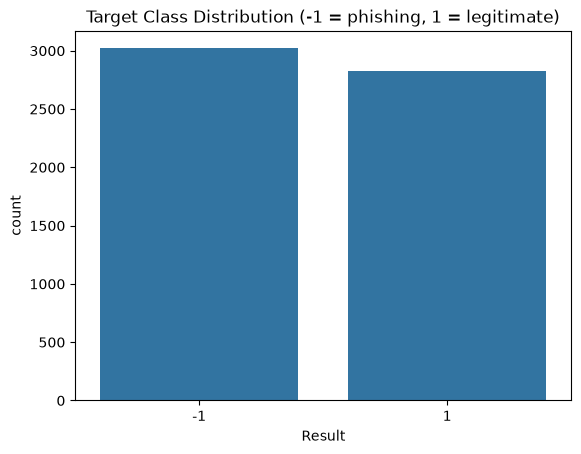

In [8]:
print(df[TARGET].value_counts())
print((df[TARGET].value_counts(normalize=True) * 100).round(2))
sns.countplot(data=df, x=TARGET)
plt.title('Target Class Distribution (-1 = phishing, 1 = legitimate)')
plt.show()

## 7. Exploratory Data Analysis

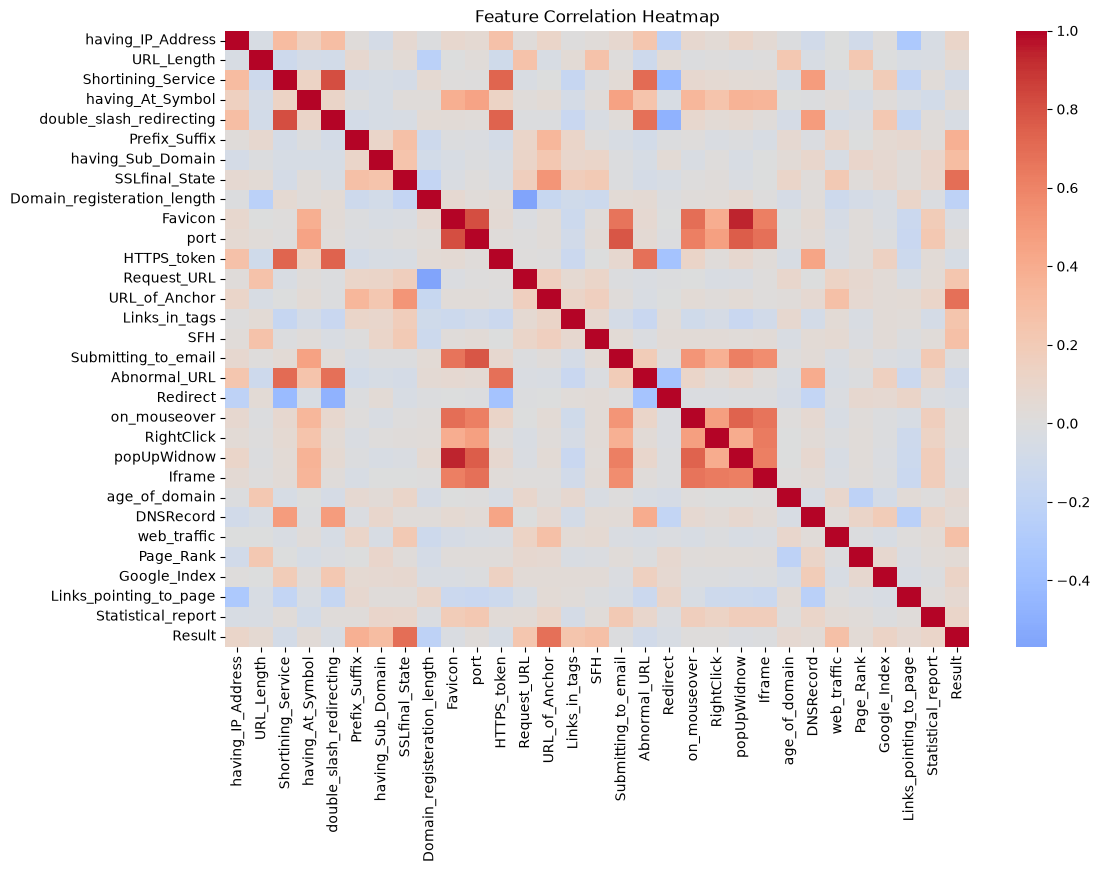

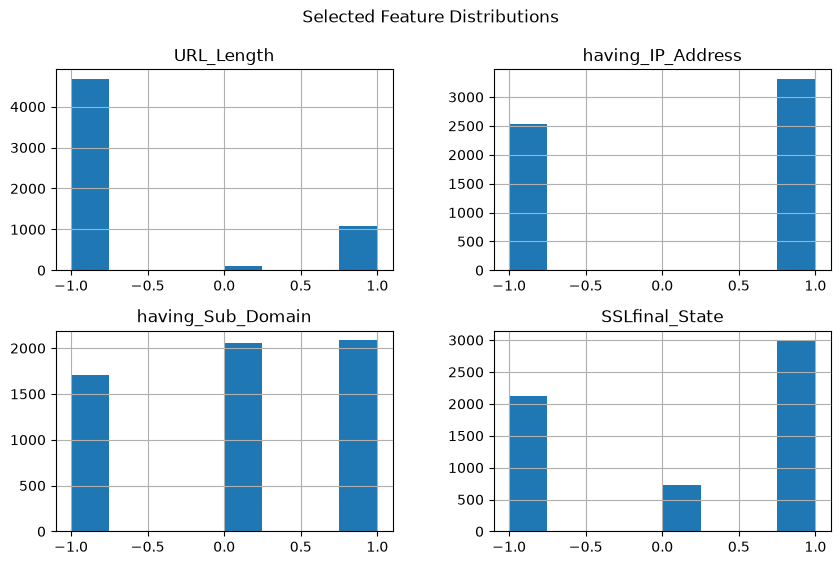

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

important_for_url = ['URL_Length', 'having_IP_Address', 'having_Sub_Domain', 'SSLfinal_State']
df[important_for_url].hist(figsize=(10, 6), bins=8)
plt.suptitle('Selected Feature Distributions')
plt.show()

## 8. Feature/Target Separation

In [10]:
# These are the only columns that can be calculated reliably from a raw URL.
FEATURE_COLUMNS = ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'HTTPS_token']
X = df[FEATURE_COLUMNS]
y = df[TARGET].astype(int)
print('Training features:', FEATURE_COLUMNS)
print('Label mapping: -1 = phishing/suspicious, 1 = legitimate/safe')

Training features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'HTTPS_token']
Label mapping: -1 = phishing/suspicious, 1 = legitimate/safe


## 9. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 10. Feature Scaling if Required

A StandardScaler is kept inside every Pipeline. It is fitted only on X_train, preventing test-set leakage. The same pipeline is saved for app inference.

## 11. Model Training

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
}
fitted = {}
for name, estimator in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    fitted[name] = pipeline

c:\Users\DELL\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 12. Model Evaluation

Logistic Regression
              precision    recall  f1-score   support

    Phishing       0.70      0.83      0.76       604
  Legitimate       0.77      0.62      0.69       566

    accuracy                           0.73      1170
   macro avg       0.74      0.73      0.72      1170
weighted avg       0.74      0.73      0.73      1170



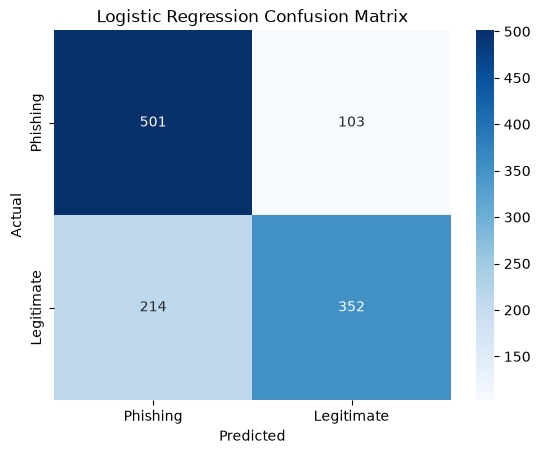

Random Forest
              precision    recall  f1-score   support

    Phishing       0.72      0.82      0.77       604
  Legitimate       0.77      0.67      0.72       566

    accuracy                           0.74      1170
   macro avg       0.75      0.74      0.74      1170
weighted avg       0.75      0.74      0.74      1170



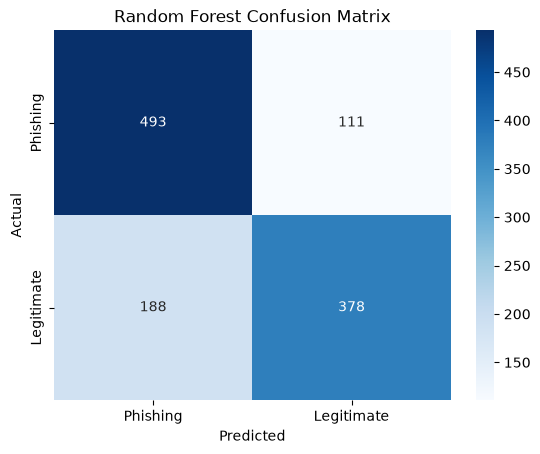

SVM
              precision    recall  f1-score   support

    Phishing       0.72      0.83      0.77       604
  Legitimate       0.78      0.66      0.71       566

    accuracy                           0.75      1170
   macro avg       0.75      0.74      0.74      1170
weighted avg       0.75      0.75      0.74      1170



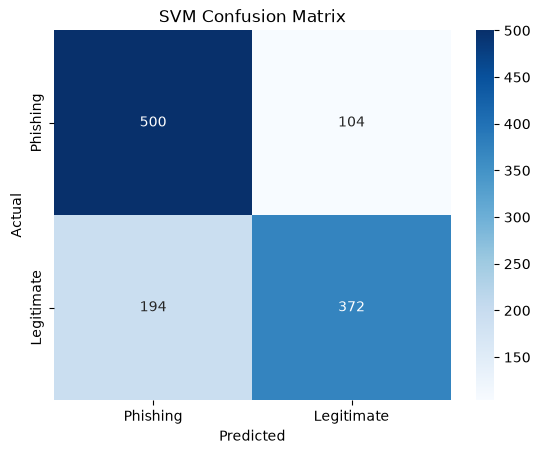

In [13]:
results = {}
for name, pipeline in fitted.items():
    prediction = pipeline.predict(X_test)
    results[name] = {'Accuracy': accuracy_score(y_test, prediction), 'Precision': precision_score(y_test, prediction, pos_label=-1), 'Recall': recall_score(y_test, prediction, pos_label=-1), 'F1 Score': f1_score(y_test, prediction, pos_label=-1)}
    print(name)
    print(classification_report(y_test, prediction, labels=[-1, 1], target_names=['Phishing', 'Legitimate'], zero_division=0))
    sns.heatmap(confusion_matrix(y_test, prediction, labels=[-1, 1]), annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 13. Model Comparison

In [9]:
comparison = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
comparison

NameError: name 'results' is not defined

## 14. Select Best Model

In [ ]:
best_name = max(results, key=lambda name: (results[name]['F1 Score'], results[name]['Recall'], results[name]['Precision']))
best_pipeline = fitted[best_name]
print('Selected:', best_name)
print('Reason: highest phishing-class F1-score, with recall and precision as tie-breakers.')

## 15. Save Model

In [ ]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(best_pipeline, MODEL_DIR / 'url_phishing_pipeline.pkl')
joblib.dump(best_pipeline, MODEL_DIR / 'url_phishing_model.pkl')

## 16. Save Preprocessing Object

In [ ]:
metadata = {'feature_columns': FEATURE_COLUMNS, 'target_column': TARGET, 'label_mapping': {-1: 'Phishing / Suspicious', 1: 'Legitimate / Safe'}, 'selected_model': best_name, 'metrics': results}
joblib.dump(metadata, MODEL_DIR / 'url_phishing_metadata.pkl')

## 17. Test Prediction

In [ ]:
from url_feature_extractor import extract_url_features
for url in ['https://www.google.com', 'https://www.wikipedia.org', 'http://192.168.1.1/login@verify']:
    row = extract_url_features(url)
    prediction = best_pipeline.predict(row)[0]
    confidence = best_pipeline.predict_proba(row).max()
    print(url, '=>', 'Phishing / Suspicious' if prediction == -1 else 'Legitimate / Safe', f'({confidence:.2%})')

# No fabricated page-level values are used. The app uses the same URL feature extractor and saved feature order.